# 11 — Sufixální morfologie vs. gramatické číslo

nb07–nb10 hledaly vysvětlení sg/pl v demografii (populace) a geografii
(region, sousedství). Tenhle notebook se ptá jinak: **souvisí gramatické
číslo se samotnou stavbou jména** — konkrétně s tím, jaký sufix předchází
`-ice`?

Motivace je lingvistická, ne statistická fishing expedition: `-ovice` je
dobře doložený produktivní patronymický formant v české onomastice — vesnice
pojmenovaná "ves lidí Novákových" (Novákovice) je svou podstatou kolektivum,
tedy přirozeně pomnožná. Pokud to v datech platí systematicky, měl by
`-ovice` mít mnohem vyšší podíl plurálu než ostatní `-ice` jména.

Kategorizace (datově řízená — viz sekce 2, `src/geogram/morphology.py`):

1. **`-ovice`** — patronymický formant (Kunovice, Sedlovice, ...)
2. **`-nice`** — zbylé varianty na -nice (-inice/-enice/-anice/...),
   jednotlivě příliš vzácné na samostatnou skupinu
3. **holé `-ice`** — souhláska přímo před -ice, heterogenní zbytek

Logika klasifikace je v modulu (`morphology.classify_suffix`), notebook jen
orchestruje — stejná konvence jako zbytek projektu.

In [1]:
import sys
from pathlib import Path

project_root = Path("..")
sys.path.insert(0, str(project_root / "src"))

import pandas as pd
import numpy as np

from geogram import viz, config, morphology

viz.set_style()

DATA = config.PROCESSED_DIR
WIKI_CSV = DATA / "ice_grammar_wiki_v2.csv"


## 1. Data

In [2]:
df = pd.read_csv(WIKI_CSV)
df = morphology.add_suffix_column(df)
print(df["wiki_number"].value_counts())

wiki_number
plural      1410
singular     233
unknown      163
Name: count, dtype: int64


## 2. Sufixální skupiny — jak vznikla kategorizace

Rozpad posledních 4–6 písmen jména ukazuje, že `-ovice` je naprosto
dominantní jednotlivý vzor (37 % všech -ice obcí), zbytek je rozptýlený do
mnoha malých variant na `-nice` a heterogenní skupiny holého `-ice`
(souhláska + ice, bez zvláštního formantu).

C:\Users\dobes\Documents\UniversityCodingProject\NewFunnyProjects\GeoGram_sufix-ice\notebooks\..\src\geogram\viz.py:1196: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[counts.get(c, 0) for c in SUFFIX_ORDER],


WindowsPath('C:/Users/dobes/Documents/UniversityCodingProject/NewFunnyProjects/GeoGram_sufix-ice/assets/img/geogram/11_suffix_overview.png')

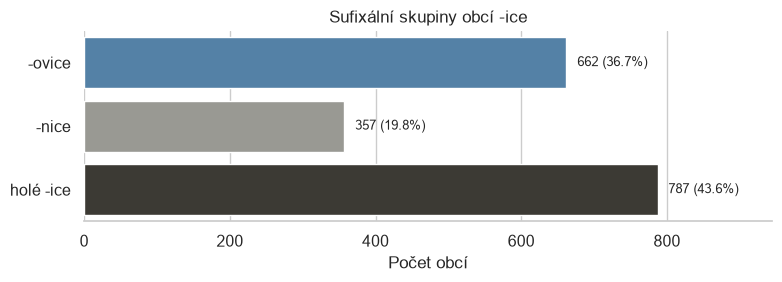

In [3]:
fig = viz.plot_suffix_overview(df)
viz.save_fig(fig, "11_suffix_overview")

## 3. Hlavní test: sg/pl podle sufixální skupiny

WindowsPath('C:/Users/dobes/Documents/UniversityCodingProject/NewFunnyProjects/GeoGram_sufix-ice/assets/img/geogram/11_by_suffix.png')

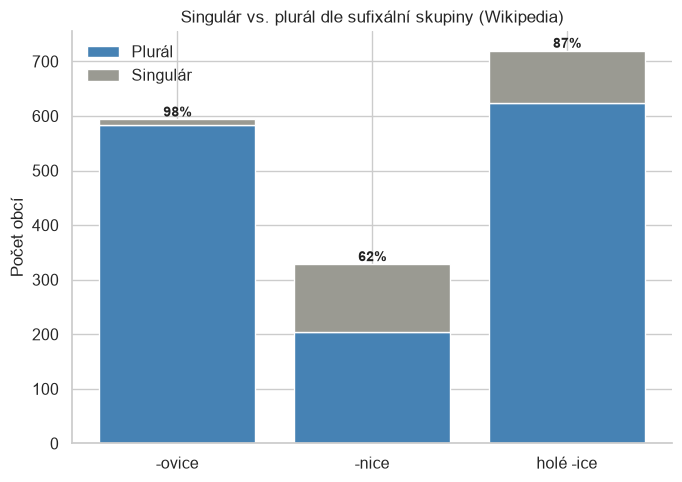

In [4]:
fig = viz.plot_by_suffix(df)
viz.save_fig(fig, "11_by_suffix")

In [5]:
t = viz.chi2_suffix_test(df)
print(t["contingency"])
print()
print(f"chi2 = {t['chi2']:.2f}, p = {t['p']:.2e}, dof = {t['dof']}")
print()
ct = t["contingency"]
print("podíl plurálu dle skupiny:")
print((ct["plural"] / (ct["plural"] + ct["singular"])).round(3))

wiki_number   plural  singular
suffix_group                  
ovice            583        11
nice             204       125
bare_ice         623        97

chi2 = 227.78, p = 3.45e-50, dof = 2

podíl plurálu dle skupiny:
suffix_group
ovice       0.981
nice        0.620
bare_ice    0.865
dtype: float64


**Zdaleka nejsilnější efekt v celém projektu.** `-ovice` je plurálové v
98 % případů (583/594, jen 11 výjimek) — prakticky kategorický, ne jen
statistický vzorec. `-nice` je naopak skupina s nejvyšším podílem singuláru
ze všech (62 % plurál, tedy 38 % singulár — víc než dvojnásobek podílu
singuláru u holého `-ice`). Chi² p ≈ 3.5×10⁻⁵⁰ — o řády silnější než
efekty populace (nb09, p≈0.045) nebo geografie (nb08/nb10).

Lingvisticky to dává smysl: `-ovice` je patronymický kolektivní formant
("ves lidí X-ových"), sémanticky přirozeně pomnožný, zatímco `-nice` a holé
`-ice` zahrnují různorodější, historicky méně jednotné vzory tvoření jmen.

## 4. Kontrola konfundů

Než se závěr vezme jako hotový, dvě otázky: (a) nekoreluje sufix náhodou
s `unknown` labelem — pokud ano, mohl by zkreslovat i vzorkovou velikost
sg/pl testu výše? (b) nekoreluje sufix s regionem (Čechy/Morava) tak silně,
že efekt sufixu je jen "geografie v přestrojení"?

In [6]:
t_unknown = viz.chi2_unknown_suffix_test(df)
print(t_unknown["contingency"])
print(f"\nchi2 = {t_unknown['chi2']:.2f}, p = {t_unknown['p']:.4f}")

status        klasifikováno  unknown
suffix_group                        
ovice                   594       68
nice                    329       28
bare_ice                720       67

chi2 = 2.11, p = 0.3479


Nevýznamné (p ≈ 0.35) — podíl `unknown` je napříč sufixálními skupinami
prakticky stejný (8–10 %). Sufix tedy nekoreluje s tím, jak dobře je
gramatické číslo extrahovatelné z Wikipedie — žádný konfundovaný vzorek.

In [7]:
t_land = viz.chi2_suffix_land_test(df)
print(t_land["contingency"])
print(f"\nchi2 = {t_land['chi2']:.2f}, p = {t_land['p']:.2e}")
print()
print("řádkové podíly (rozmístění sufixální skupiny napříč zeměmi):")
ct = t_land["contingency"]
print((ct.T / ct.sum(axis=1)).T.round(3))

land          Morava  Morava+Slezsko  Vysočina  Čechy
suffix_group                                         
ovice            158             103        62    339
nice              70              22        32    233
bare_ice         161              74        64    488

chi2 = 35.67, p = 3.20e-06

řádkové podíly (rozmístění sufixální skupiny napříč zeměmi):
land          Morava  Morava+Slezsko  Vysočina  Čechy
suffix_group                                         
ovice          0.239           0.156     0.094  0.512
nice           0.196           0.062     0.090  0.653
bare_ice       0.205           0.094     0.081  0.620


Sufix **je** slabě, ale významně vázaný na region (p ≈ 3.2×10⁻⁶) —
`-ovice` je o něco častější na Moravě a Moravě+Slezsku (40 % vs. ~26–30 %
u ostatních skupin) než v Čechách. Otázka tedy je: přežije efekt sufixu na
sg/pl, když se region drží konstantní?

In [8]:
strat = viz.chi2_land_test_by_suffix(df)
for grp, r in strat.items():
    warn = "  [POZOR: očekávané četnosti < 5, chi2 nespolehlivý]" if r["low_count_warning"] else ""
    print(f"{grp:10s}  n={r['n']:4d}  chi2={r['chi2']:6.2f}  p={r['p']:.4f}{warn}")
    print(r["contingency"])
    print()

ovice       n= 594  chi2=  8.19  p=0.0422  [POZOR: očekávané četnosti < 5, chi2 nespolehlivý]
wiki_number     plural  singular
land                            
Morava             152         1
Morava+Slezsko      91         0
Vysočina            61         0
Čechy              279        10

nice        n= 329  chi2=  1.23  p=0.7450
wiki_number     plural  singular
land                            
Morava              47        23
Morava+Slezsko      13         9
Vysočina            20        11
Čechy              124        82

bare_ice    n= 720  chi2=  8.23  p=0.0414
wiki_number     plural  singular
land                            
Morava             147        11
Morava+Slezsko      55        10
Vysočina            51        12
Čechy              370        64



**Stratifikovaný pohled:** uvnitř skupiny `-nice` region na sg/pl vůbec
nepůsobí (p ≈ 0.75) — regionální efekt z nb07/nb08 se tam ztrácí. Uvnitř
`bare_ice` zůstává region slabě významný (p ≈ 0.041), podobně jako uvnitř
`-ovice` (p ≈ 0.042) — ale u `-ovice` je jen 11 singulárových obcí na celé
ČR rozdělených do 4 regionů, takže víc než polovina buněk kontingenční
tabulky má očekávanou četnost pod 5 a chi² aproximace tam formálně neplatí
(označeno výše). Efekt `-ovice` → plurál je tak silný a rovnoměrný napříč
regiony (152/153 na Moravě, 279/289 v Čechách — všude přes 98 %), že
"testovat" ho na tomhle vzorku nemá smysl — je prakticky kategorický
bez ohledu na region.

**Závěr kontroly konfundů:** efekt sufixu na sg/pl (sekce 3) není jen
odražená geografie — u `-ovice` je silnější a rovnoměrnější než cokoli, co
region sám vysvětluje; u `-nice` region efekt vůbec nemá. Regionální signál
z nb07/nb08 přežívá jen v heterogenní `bare_ice` skupině, a i tam jen slabě.

## 5. Bonus: jemnější pohled na jednotlivé koncovky

Popisný (netestovaný) graf — 3 hlavní skupiny skrývají docela širokou
škálu uvnitř sebe. Zajímavé pro morfologickou intuici, i když skupiny jsou
příliš malé/početné na formální test.

WindowsPath('C:/Users/dobes/Documents/UniversityCodingProject/NewFunnyProjects/GeoGram_sufix-ice/assets/img/geogram/11_suffix_detail.png')

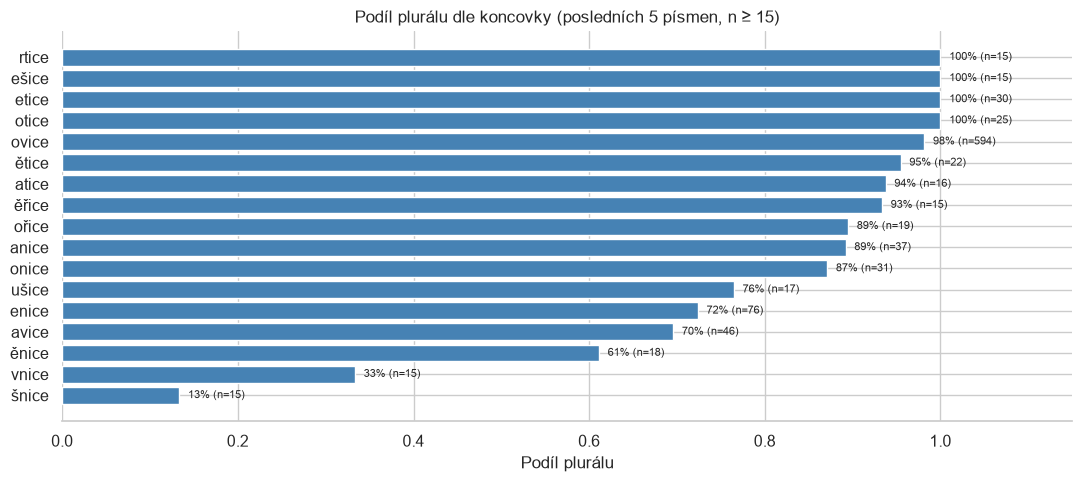

In [9]:
fig = viz.plot_suffix_detail(df, min_n=15)
viz.save_fig(fig, "11_suffix_detail")

Rozpětí je velké: `-šnice` je jen 13 % plurálové (téměř vždy singulár),
zatímco `-otice`, `-etice`, `-ešice`, `-rtice` a samozřejmě `-ovice` jsou
100% (nebo skoro 100%) plurálové. To naznačuje, že "3 skupiny" ze sekce 3
jsou zjednodušení — v `-nice`/`bare_ice` skupinách je pravděpodobně víc
jemnější morfologické struktury, než tenhle projekt zatím systematicky
zmapoval (možný next step, viz shrnutí).

## 6. Shrnutí

**Sufixální morfologie je zdaleka nejsilnější prediktor sg/pl nalezený v
celém projektu** — silnější než populace (nb09) i geografie (nb08/nb10),
o desítky řádů v p-value, a hlavně: dává přímý lingvistický smysl.
`-ovice` (patronymický formant) je téměř kategoricky plurálové (98 %,
p ≈ 3.5×10⁻⁵⁰), konzistentně napříč celou ČR — silnější a stabilnější
efekt než jakýkoli regionální nebo demografický vzorec.

Kontrola konfundů (sekce 4) ukázala, že efekt není artefakt regionálního
rozmístění sufixů — přežívá (nebo dokonce je silnější) uvnitř regionů,
ne díky nim. `unknown` label na sufixu vůbec nezávisí (p ≈ 0.35) — žádné
riziko zkresleného vzorku.

**Pro článek:** tohle je pravděpodobně hlavní zjištění celého projektu —
"gramatické číslo obcí na -ice není náhodné ani jen demografické/geografické,
je to především otázka slovotvorby" je silnější a čtenářsky zajímavější
titulek než cokoli z nb07–nb10 samostatně. Stálo by za to v článku otevřít
tímhle zjištěním, ne ho nechat jako poslední notebook.

**Next steps:**
1. Systematičtější morfologická klasifikace (sekce 5 naznačuje, že 3
   skupiny jsou hrubé — jemnější sufixální rodiny by mohly vysvětlit ještě
   víc, zvlášť uvnitř `-nice`/`bare_ice`).
2. Až dorazí IJP ÚJČ data, zopakovat `chi2_suffix_test` na nich — pokud
   `-ovice`→plurál efekt drží i na nezávislém zdroji, je to silný důkaz, že
   jde o skutečný morfologický jev, ne artefakt Wikipedia extrakce.